intro:
(as per discussion post)

glossary of fields, which get encoded and how and why

plan:
-preprocess
-encode
-supporting charts to understand data, distributions etc
    - convert percentages
    - distributions graphs
    - exit rates
-logistic regression (explain why this model and others..strenghts/weaknesses)
-descision tree
-random forest
-sampling or way to make data more accurate, bootstrapping?




analysis:
-with and without pagevalues
-f1 score, confusion matrix
-aic and bic?  no roc/auc

conclusion:
- discuss conclusions 
- model performance, are the more complex better, did we tune them, why

### Final Project - Online Shoppers Purchasing Intention Dataset

Dataset main page: [here](https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention+dataset)

Dataset zip file: [here](https://archive.ics.uci.edu/static/public/468/online+shoppers+purchasing+intention+dataset.zip)


The dataset is from the *UCI Machine Learning Repository*.  The data models user behavior on a popular e-commerce site to predict the intent to make a purchase.

Note: The feature metrics relate to user behavior, such as time on a page, page type visited, time of year (special events), and bounce and exit rates. 

**Objective:**
- The question we are trying to solve is: **will a session result in a purchase.**
- This information is valuable because it can reveal which parts of the user journey on the e-commerce site add friction to the user's experience, thus causing undesirable behavior (high bounce/exit rates or no purchase).
- The strength of this data is that it models user behavior

**Dataset Details:**

- Contains feature vectors from 12,300 user sessions
- Each session belongs to a different user over a 1-year period, which helps avoid behavioral bias toward events, periods, or a specific user profile.
- The target variable is 'Revenue' and is labeled as a boolean (true/false), making the dataset appropriate for a supervised classification model.

- The model is a classification model because the target variable 'Revenue' is binary (purchased or not purchased).
- There are a number of categorical features that will be converted using **One Hot Encoding**:
    - Month (month of year)
    - OperatingSystems (type of OS the user is on)
    - Browser (type of browser the user is on)
    - Region (geographic region)
    - TrafficType (how did the user arrive here: search, referral, other)
    - VisitorType (new visitor, returning)
    - Weekend (boolean)
- The other features are continuous and will need to be scaled so that models (specifically for Logistic Regression) do not give too much weight to larger values 
    - page counts (Administrative, Informational, ProductRelated)
    - page durations (Administrative, Informational, ProductRelated)
    - bounce rate (% of 1 page view sessions)
    - exit rate (% of a page being the last in a session)
    - page value (page rank of a page if the session converted - consider dropping due to data leakage)
    - special day score (rank of how close the session is to a holiday)



**Model Selection:**

_Logistic Regression_ will provide a logical choice for a baseline model.  It works well for this binary classification model.  It can show which features are associated with a higher/lower probability of a purchase.

_Decision Trees_ will be interesting to compare with Logistic Regression, a decision tree can show how feature combinations result in a purchase or non-purchase.  Seeing this visually in a tree diagram will make it easy to interpret.

Since we're using Decision Trees, we should go a step further and run the data through a _Random Forest_.  This will be beneficial by reducing overfitting.  Some relationships may be complex resulting in the model learning 'too well' and thus overfitting.

**Data Exploration**
Provide a series of graphs to help visualize how the data is generally structured.  These graphs will not fully explain the model, but they indicate which features influence the outcome the most.  And they intuitively describe user behavior in the real world


**Feature Selection**

We'll use the VIF — Variance Inflation Factor to check for multicollinearity.  For simplicity sake, once features are identified as redundant, we'll drop for all models.  This keeps the comparison between models simpler and more consistent


**Evaluation**

Model performance will be evaluated using a confusion matrix, accuracy, precision, recall, and F1-score. Since purchases may be less common than non-purchases, I will not rely only on accuracy. I will likely prioritize F1-score because it balances precision and recall.

##### Setup imports 

In [46]:
# setup standard imports for data analysis and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns   
import statsmodels.api as sm

# modeling and evaluation
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import warnings
from statsmodels.stats.outliers_influence import variance_inflation_factor


##### Step 1 - Data Cleaning

We can see our data is in good shape, with no missing values per column and a typical split on revenue across the data set at about 15% purchase and 85% no purchase. We also remove `PageValues` during cleaning because it is too directly tied to conversion and would leak target information into the models.

In [47]:
# read data in a global variable so it can be used in other cells


data_path = "online-shoppers-intention.csv"
df = pd.read_csv(data_path)
target_column = "Revenue"
# make a working copy and convert boolean style values into numeric form to match the other columns and make it easier to work with
working_df = df.copy()
working_df["Weekend"] = working_df["Weekend"].astype(str).str.upper().map({"TRUE": 1, "FALSE": 0})
working_df["Revenue"] = working_df["Revenue"].astype(str).str.upper().map({"TRUE": 1, "FALSE": 0})


duplicate_rows = working_df.duplicated().sum()
working_df = working_df.drop_duplicates().reset_index(drop=True)
working_df = working_df.drop(columns=["PageValues"])
clean_df = working_df.copy()

print("missing values by column:")
print(working_df.isna().sum())

print("duplicate rows removed:", duplicate_rows)
print("\n")
print(f"total rows: {working_df.shape[0]}")
print("\n")
print(f"total columns: {working_df.shape[1]}")
print("\n")
print("class balance:")
print(working_df[target_column].value_counts(normalize=True).rename("proportion"))


missing values by column:
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64
duplicate rows removed: 125


total rows: 12205


total columns: 17


class balance:
Revenue
0    0.843671
1    0.156329
Name: proportion, dtype: float64


#### Step 1 - Exploratory Data Analysis

- Purchase Rate by Month: Helps to identify seasonal patterns in the purchase decision.  Somewhat expected, purchase rates rise as we approach the holiday season.


- Purchase vs Non Purchase: We ran the 'class balance' above, though a visualization is easier to interpret.  It does highlight the low purchase rate, and the fact the model has less of a signal to learn from for the purchase class.  This leads us to rely on the confusion matrix and the F1 score, recall and precision are more important than only looking at the accuracy.  


- Purchase Rate by Visitor Type: My intuition here would tell me that return visitors are more likely to purchase, however that is not the case as new visitors were the class that had the highest rate.


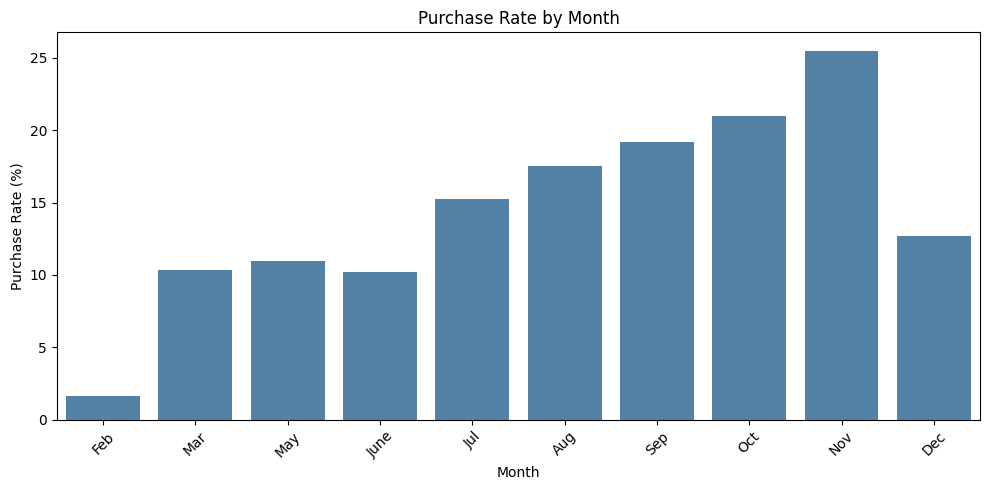

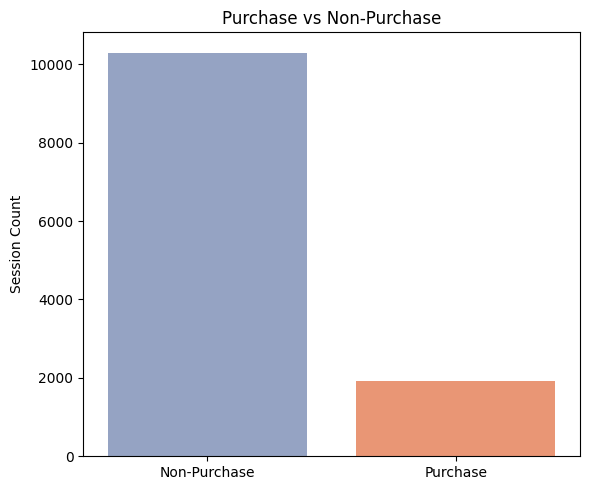

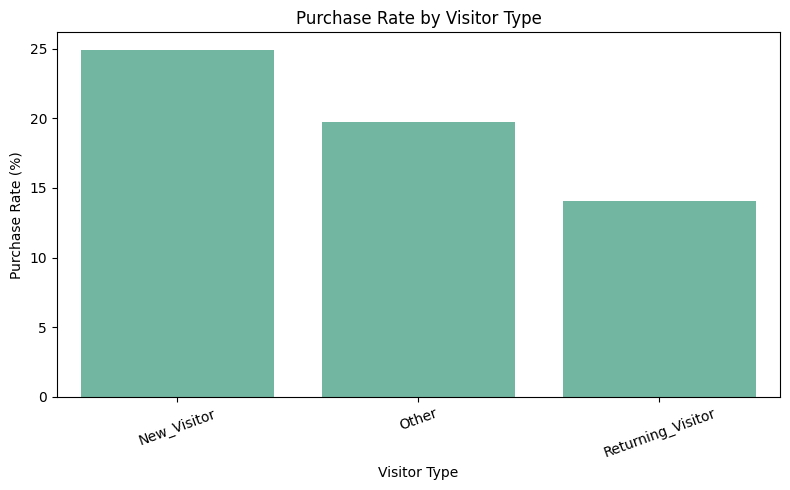

In [57]:
# Purchase Rate by Month
month_order = [
    "Jan", "Feb", "Mar", "Apr", "May", "June",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec",
]

month_purchase_rate = (
    clean_df.groupby("Month")["Revenue"]
    .mean()
    .reindex(month_order)
    .dropna()
    .mul(100)
    .reset_index(name="PurchaseRate")
)

plt.figure(figsize=(10, 5))
sns.barplot(data=month_purchase_rate, x="Month", y="PurchaseRate", color="steelblue")
plt.title("Purchase Rate by Month")
plt.xlabel("Month")
plt.ylabel("Purchase Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Purchase vs Non Purchase
purchase_labels = clean_df["Revenue"].map({0: "Non-Purchase", 1: "Purchase"})
purchase_counts = purchase_labels.value_counts().reindex(["Non-Purchase", "Purchase"]).reset_index()
purchase_counts.columns = ["Outcome", "Count"]

plt.figure(figsize=(6, 5))
sns.barplot(
    data=purchase_counts,
    x="Outcome",
    y="Count",
    hue="Outcome",
    palette=["#8da0cb", "#fc8d62"],
    dodge=False,
    legend=False,
 )
plt.title("Purchase vs Non-Purchase")
plt.xlabel("")
plt.ylabel("Session Count")
plt.tight_layout()
plt.show()

# Purchase Rate by Visitor Type
visitor_purchase_rate = (
    clean_df.groupby("VisitorType")["Revenue"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .reset_index(name="PurchaseRate")
)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=visitor_purchase_rate,
    x="VisitorType",
    y="PurchaseRate",
    color="#66c2a5",
 )
plt.title("Purchase Rate by Visitor Type")
plt.xlabel("Visitor Type")
plt.ylabel("Purchase Rate (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

##### Step 2 - One Hot Encode Data

One hot encode the categorical values: (_Month, OperatingSystems, Browser, Region, TrafficType, and VisitorType_)

After dropping `PageValues` and using `drop_first=True`, our column count goes from 17 to 68.
This keeps one baseline category out of each dummy-variable group, which is especially helpful for the logistic regression and VIF analysis.
A snippet of the first 5 rows of the data is shown with all columns, including the one-hot encoded ones.

In [48]:
# one hot encode categorical columns
working_df = clean_df.copy()

categorical_features = [
    "Month",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "VisitorType",
]

columns_to_encode = [
    column for column in categorical_features if column in working_df.columns
]

if columns_to_encode:
    working_df = pd.get_dummies(
        working_df,
        columns=columns_to_encode,
        drop_first=True,
        dtype=int,
    )

encoded_df = working_df.copy()

print(f"encoded shape: {encoded_df.shape}")
with pd.option_context("display.max_columns", None):
    display(encoded_df.head())

encoded shape: (12205, 68)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,SpecialDay,Weekend,Revenue,Month_Dec,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,OperatingSystems_2,OperatingSystems_3,OperatingSystems_4,OperatingSystems_5,OperatingSystems_6,OperatingSystems_7,OperatingSystems_8,Browser_2,Browser_3,Browser_4,Browser_5,Browser_6,Browser_7,Browser_8,Browser_9,Browser_10,Browser_11,Browser_12,Browser_13,Region_2,Region_3,Region_4,Region_5,Region_6,Region_7,Region_8,Region_9,TrafficType_2,TrafficType_3,TrafficType_4,TrafficType_5,TrafficType_6,TrafficType_7,TrafficType_8,TrafficType_9,TrafficType_10,TrafficType_11,TrafficType_12,TrafficType_13,TrafficType_14,TrafficType_15,TrafficType_16,TrafficType_17,TrafficType_18,TrafficType_19,TrafficType_20,VisitorType_Other,VisitorType_Returning_Visitor
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1


##### Step 3 - Normalize numeric features

In [52]:
numeric_features = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "SpecialDay",
    "Weekend",
]

target = "Revenue"
y = encoded_df[target].copy()
X_selected = encoded_df.drop(columns=[target]).copy()
X_tree = X_selected.copy()
X_logistic = X_selected.copy()

scaler = StandardScaler()
X_logistic[numeric_features] = scaler.fit_transform(X_logistic[numeric_features])

print(f"X_tree shape: {X_tree.shape}")
print(f"X_logistic shape: {X_logistic.shape}")
print(f"y shape: {y.shape}")
X_logistic[numeric_features].head()

X_tree shape: (12205, 67)
X_logistic shape: (12205, 67)
y shape: (12205,)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,SpecialDay,Weekend
0,-0.702302,-0.460019,-0.398824,-0.246257,-0.696218,-0.628793,3.969402,3.434394,-0.31024,-0.553088
1,-0.702302,-0.460019,-0.398824,-0.246257,-0.673793,-0.595451,-0.450137,1.268054,-0.31024,-0.553088
2,-0.702302,-0.460019,-0.398824,-0.246257,-0.696218,-0.628793,3.969402,3.434394,-0.31024,-0.553088
3,-0.702302,-0.460019,-0.398824,-0.246257,-0.673793,-0.627404,0.654748,2.134590,-0.31024,-0.553088
4,-0.702302,-0.460019,-0.398824,-0.246257,-0.494387,-0.301889,-0.008183,0.184884,-0.31024,1.808031


##### Step 4a - Feature Selection

Using the VIF score, we can remove features that may lead to multicollinearity. This matters most for logistic regression. Because the categorical variables were one-hot encoded with `drop_first=True`, the VIF results are more realistic and easier to interpret than they were with a full dummy set.

The `drop_first=True` helped reduce the number of features flagged with a high VIF, prior to that one hot encoding change, we had 65 features flagged and now we have 8, which is much more reasonable, we want to use as many features as possible for a decent prediction model, but don't want to skew the logistic regression model too much by taking out a high number of features

In [50]:

# standard threshold for VIF 
vif_threshold = 5.0
vif_input = X_logistic.astype(float).copy()

# suppress divide by zero warnings since we will be checking for infinite VIF values in the next step
with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore",
        message="divide by zero encountered in scalar divide",
        category=RuntimeWarning,
    )

    vif_scores = pd.DataFrame(
        {
            "feature": vif_input.columns,
            "VIF": [
                variance_inflation_factor(vif_input.values, index)
                for index in range(vif_input.shape[1])
            ],
        }
    ).sort_values("VIF", ascending=False).reset_index(drop=True)

high_vif_features = vif_scores[
    (vif_scores["VIF"] >= vif_threshold) | np.isinf(vif_scores["VIF"])
] .copy()

print(f"features with VIF >= {vif_threshold}: {len(high_vif_features)}")
display(high_vif_features)

features with VIF >= 5.0: 9


,feature,VIF
0,Browser_11,inf
1,OperatingSystems_5,inf
2,Browser_2,19.976593
3,OperatingSystems_2,16.661382
4,VisitorType_Returning_Visitor,7.243393
5,OperatingSystems_3,7.118245
6,ExitRates,6.440576
7,BounceRates,5.793424
8,Month_May,5.120574


##### Step 4b - Feature Selection Filter

As part of the feature selection, let's remove the high VIF features from our data set.  Note that drop the features on the original data set, then we copy into 2 distinct sets again for logistic and the tree models.
We have to rescale the data since we dropped some features.

In [53]:
features_to_drop = high_vif_features["feature"].tolist()

# drop the features on the original X datasets 
y = encoded_df[target].copy()
X_selected = encoded_df.drop(
    columns=[target] + features_to_drop,
    errors="ignore",
).copy()
X_tree = X_selected.copy()
X_logistic = X_selected.copy()

remaining_numeric_features = [
    feature for feature in numeric_features if feature in X_logistic.columns
]

# since we dropped some features, we need to re-scale the remaining numeric features to ensure they are on the same scale for logistic regression
scaler = StandardScaler()
X_logistic[remaining_numeric_features] = scaler.fit_transform(
    X_logistic[remaining_numeric_features]
 )

print(f"dropped features: {len(features_to_drop)}")
print(features_to_drop)
print(f"X_tree shape after VIF drop: {X_tree.shape}")
print(f"X_logistic shape after VIF drop: {X_logistic.shape}")

dropped features: 9
['Browser_11', 'OperatingSystems_5', 'Browser_2', 'OperatingSystems_2', 'VisitorType_Returning_Visitor', 'OperatingSystems_3', 'ExitRates', 'BounceRates', 'Month_May']
X_tree shape after VIF drop: (12205, 58)
X_logistic shape after VIF drop: (12205, 58)


##### Step 5 - Split data and model analysis 

First, we'll split the data into a 80% training and 20% testing groups

In [59]:
# use stratified sampling to ensure the same class balance in train and test sets since the target is imbalanced
# we'll use the same train test split for both logistic regression and tree based models to ensure a fair comparison
X_logistic_train, X_logistic_test, X_tree_train, X_tree_test, y_train, y_test = train_test_split(
    X_logistic,
    X_tree,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
 )



##### Step 5a - Logistic Regression

In [60]:
logistic_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_model.fit(X_logistic_train, y_train)

y_logistic_pred = logistic_model.predict(X_logistic_test)

logistic_accuracy = accuracy_score(y_test, y_logistic_pred)
logistic_precision = precision_score(y_test, y_logistic_pred)
logistic_recall = recall_score(y_test, y_logistic_pred)
logistic_confusion = confusion_matrix(y_test, y_logistic_pred)

print(f"Logistic Regression Accuracy: {logistic_accuracy:.4f}")
print(f"Logistic Regression Precision: {logistic_precision:.4f}")
print(f"Logistic Regression Recall: {logistic_recall:.4f}")
print("Logistic Regression Confusion Matrix:")
print(logistic_confusion)
print("\nClassification Report:")
print(classification_report(y_test, y_logistic_pred))

Logistic Regression Accuracy: 0.8423
Logistic Regression Precision: 0.4444
Logistic Regression Recall: 0.0314
Logistic Regression Confusion Matrix:
[[2044   15]
 [ 370   12]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.99      0.91      2059
           1       0.44      0.03      0.06       382

    accuracy                           0.84      2441
   macro avg       0.65      0.51      0.49      2441
weighted avg       0.78      0.84      0.78      2441



##### Step 5b - Decision Tree

In [61]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_tree_train, y_train)

y_tree_pred = tree_model.predict(X_tree_test)

tree_accuracy = accuracy_score(y_test, y_tree_pred)
tree_precision = precision_score(y_test, y_tree_pred)
tree_recall = recall_score(y_test, y_tree_pred)
tree_confusion = confusion_matrix(y_test, y_tree_pred)

print(f"Decision Tree Accuracy: {tree_accuracy:.4f}")
print(f"Decision Tree Precision: {tree_precision:.4f}")
print(f"Decision Tree Recall: {tree_recall:.4f}")
print("Decision Tree Confusion Matrix:")
print(tree_confusion)
print("\nClassification Report:")
print(classification_report(y_test, y_tree_pred))

Decision Tree Accuracy: 0.7730
Decision Tree Precision: 0.2749
Decision Tree Recall: 0.2749
Decision Tree Confusion Matrix:
[[1782  277]
 [ 277  105]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.87      0.87      2059
           1       0.27      0.27      0.27       382

    accuracy                           0.77      2441
   macro avg       0.57      0.57      0.57      2441
weighted avg       0.77      0.77      0.77      2441



##### Step 5c - Random Forest

In [62]:
from sklearn.ensemble import RandomForestClassifier

forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
 )
forest_model.fit(X_tree_train, y_train)

y_forest_pred = forest_model.predict(X_tree_test)

forest_accuracy = accuracy_score(y_test, y_forest_pred)
forest_precision = precision_score(y_test, y_forest_pred)
forest_recall = recall_score(y_test, y_forest_pred)
forest_confusion = confusion_matrix(y_test, y_forest_pred)

print(f"Random Forest Accuracy: {forest_accuracy:.4f}")
print(f"Random Forest Precision: {forest_precision:.4f}")
print(f"Random Forest Recall: {forest_recall:.4f}")
print("Random Forest Confusion Matrix:")
print(forest_confusion)
print("\nClassification Report:")
print(classification_report(y_test, y_forest_pred))

Random Forest Accuracy: 0.8353
Random Forest Precision: 0.3529
Random Forest Recall: 0.0628
Random Forest Confusion Matrix:
[[2015   44]
 [ 358   24]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.98      0.91      2059
           1       0.35      0.06      0.11       382

    accuracy                           0.84      2441
   macro avg       0.60      0.52      0.51      2441
weighted avg       0.77      0.84      0.78      2441



##### Step 5c - Model Comparison

The logistic regression model produced the highest overall accuracy, but its recall for purchases was extremely low, which means it mostly predicted the majority non-purchase class and missed most true buyers.

The decision tree had the lowest accuracy, but it found substantially more actual purchases than logistic regression, so it was more willing to identify the minority class.

The random forest improved on the single decision tree in overall accuracy, but its recall remained fairly low, so it still struggled to capture many purchase sessions.

This pattern shows the tradeoff clearly: logistic regression was the most conservative, the decision tree was the most aggressive at finding purchases, and the random forest sat between them.
Because the target is imbalanced, F1-score, precision, and recall are more informative than accuracy alone, and on that basis the decision tree and random forest were more useful than logistic regression for detecting purchases.

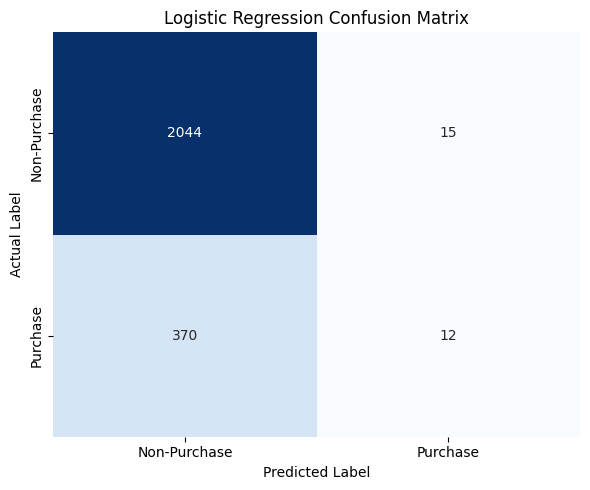

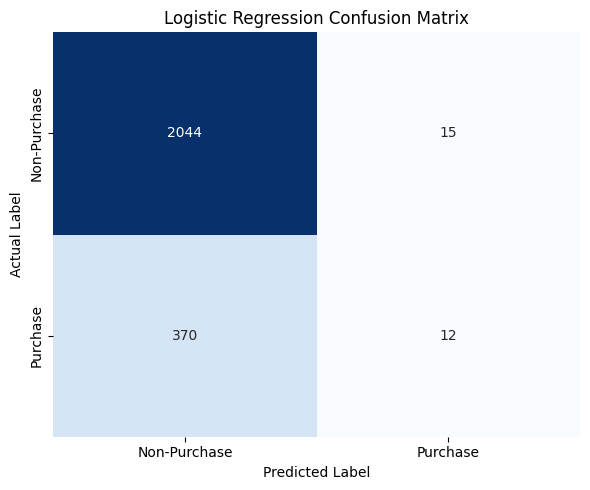

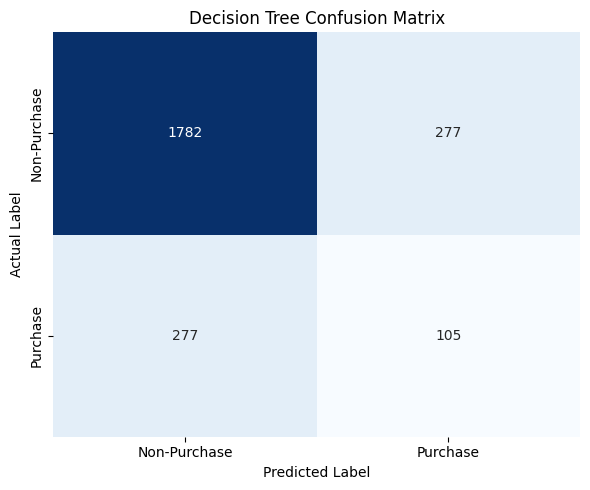

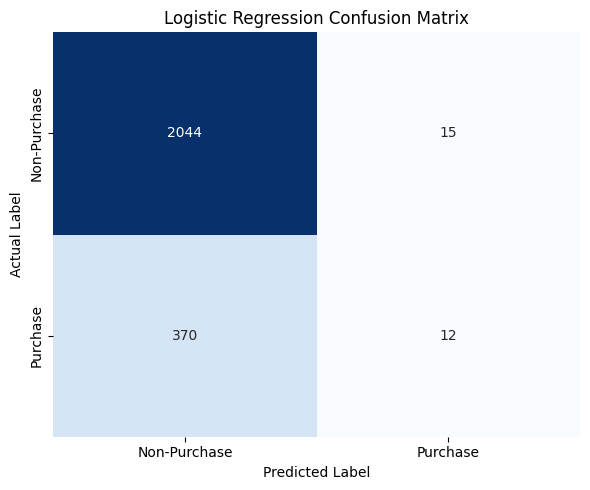

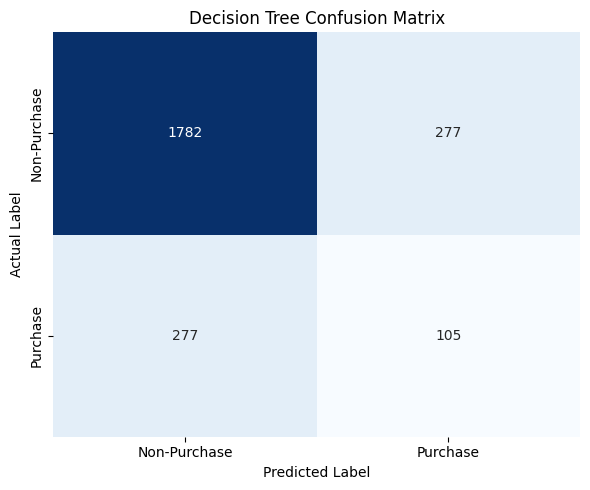

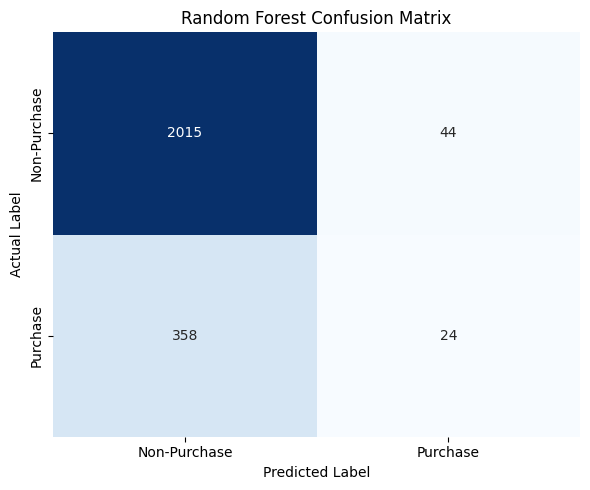

In [73]:
confusion_matrices = [
    ("Logistic Regression", logistic_confusion),
    ("Decision Tree", tree_confusion),
    ("Random Forest", forest_confusion),
]

class_labels = ["Non-Purchase", "Purchase"]

for title, matrix in confusion_matrices:
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=class_labels,
        yticklabels=class_labels,
    )
    plt.title(f"{title} Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")
    plt.tight_layout()
    plt.show()in

##### Step 5d - Model Comparison Continued